# Diffusion Transformer as High-Energy Physics Surrogate



The objective of this tutorial is to introduce the fundamental concepts behind modern generative models, with a particular focus on Denoising Diffusion Probabilistic Models (DDPMs), and to demonstrate how these models can be applied to simulation and reconstruction problems in High Energy Physics. By the end of the tutorial, participants will understand the diffusion process, train a simple DDPM implementation in Python, and gain practical insight into adapting diffusion models for calorimeter shower generation and related HEP applications.

In [ ]:
import os
import sys

REPO = "https://github.com/X-T-Nguyen/Diffusion_Model_Tutorial_for_The_first_MLQC4FC_Training_School.git"

if not os.path.exists("/content/Diffusion_Model_Tutorial_for_The_first_MLQC4FC_Training_School"):
    !git clone $REPO

sys.path.insert(
    0,
    "/content/Diffusion_Model_Tutorial_for_The_first_MLQC4FC_Training_School"
)

In [61]:
from IPython.display import Image

import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from skimage.transform import resize

import torch
import torch.nn as nn
import torch.distributed as dist
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.distributed import DistributedSampler
from torchvision import transforms
from torchvision.utils import save_image

import time
import math
import random
import os
from collections import OrderedDict
from copy import deepcopy

from timm.models.vision_transformer import PatchEmbed, Attention, Mlp

from diffusion import create_diffusion

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

False
CPU


## Overview

### Methodology


![Alt Text](Images/ddpm_scheme.png)

### Studying Case: Fast Calorimeter Simulation Challenge 2022 (Dataset 2)

Image![Alt Text](Images/Calo.png)

## Data Preparation

In [9]:
!wget -O dataset_2_1_10k.hdf5 \
"https://zenodo.org/records/22640769/files/dataset_2_1_10k.hdf5?download=1"

--2026-09-07 12:08:47--  https://zenodo.org/records/22640769/files/dataset_2_1_10k.hdf5?download=1
Resolving zenodo.org (zenodo.org)... 2001:1458:d00:3b::100:4d6, 2001:1458:d00:17::100:1d9, 2001:1458:d00:13::100:f2, ...
Connecting to zenodo.org (zenodo.org)|2001:1458:d00:3b::100:4d6|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 134219567 (128M) [application/octet-stream]
Saving to: ‘dataset_2_1_10k.hdf5’

dataset_2_1_10k.hdf 100%[===================>] 128.00M  7.04MB/s    in 19s     

2026-09-07 12:09:06 (6.67 MB/s) - ‘dataset_2_1_10k.hdf5’ saved [134219567/134219567]



In [13]:
H5_PATH = "dataset_2_1_10k.hdf5"

with h5py.File(H5_PATH, "r") as f:
    for key in f:
        print(key, f[key].shape)

incident_energies (10000, 1)
showers (10000, 6480)


In [11]:

with h5py.File(H5_PATH, "r") as f:
    energies = f["incident_energies"][:]
    showers = f["showers"][:]

In [12]:
print("=== INCIDENT ENERGIES ===")
print(f"Shape:    {energies.shape}")
print(f"Min:      {energies.min()}")
print(f"Max:      {energies.max()}")
print(f"Mean:     {energies.mean()}")
print(f"Median:   {np.median(energies)}")
print(f"Std:      {energies.std()}")

print("\n=== SHOWERS ===")
print(f"Shape:    {showers.shape}")
print(f"Min:      {showers.min()}")
print(f"Max:      {showers.max()}")
print(f"Mean:     {showers.mean()}")
print(f"Median:   {np.median(showers)}")
print(f"Std:      {showers.std()}")

=== INCIDENT ENERGIES ===
Shape:    (10000, 1)
Min:      1000.7108708476147
Max:      999564.2556472239
Mean:     141964.18441567727
Median:   29921.712116528623
Std:      225109.07461328333

=== SHOWERS ===
Shape:    (10000, 6480)
Min:      0.0
Max:      4248.93169359166
Mean:     17.08694577425274
Median:   0.0
Std:      99.14862935679035


In [62]:
# --- adjust to your geometry ---
LAYERS, N_ALPHA, N_R = 45, 12, 12   # matches your shower.reshape(45, 12, 12)

def _mirror_radial(img_r_first):
    """Moves radial bin 0 (shower core) to the middle row and mirrors
    outward, purely for a nicer plot (no new information added)."""
    return np.concatenate([img_r_first[:0:-1], img_r_first], axis=0)

def plot_longitudinal(showers, energies_mev, n_show=5):
    """showers: (N, layers, n_alpha, n_r). Longitudinal (depth vs radius) view,
    summed over the angular axis."""
    n_show = min(n_show, len(showers))
    fig, axes = plt.subplots(1, n_show, figsize=(3.2 * n_show, 3.2), squeeze=False)

    for i in range(n_show):
        img = showers[i].sum(axis=1)  # (layers, n_r) - summed over angular bins
        img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
        n_r = img.shape[1]

        img_mirrored = _mirror_radial(img.T)  # (2*n_r-1, layers), core row centered
        vmax = img_mirrored.max() if img_mirrored.max() > 1e-2 else 1e-1

        ax = axes[0][i]
        im = ax.imshow(
            img_mirrored + 1e-3,
            norm=LogNorm(vmin=1e-2, vmax=vmax),
            aspect="auto", origin="lower", cmap="inferno",
        )
        ax.set_title(f"E_inc≈{energies_mev[i]/1000:.1f} GeV")
        ax.set_xlabel("layer (depth)")
        if i == 0:
            ax.set_ylabel("radial bin")
        ax.set_yticks([0, n_r - 1, 2 * n_r - 2])
        ax.set_yticklabels([f"-{n_r - 1}", "0", f"{n_r - 1}"])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="MeV")

    plt.tight_layout()
    plt.show()

def plot_transverse(showers, energies_mev, n_show=5):
    """showers: (N, layers, n_alpha, n_r). Head-on polar view, summed over depth."""
    n_show = min(n_show, len(showers))
    fig, axes = plt.subplots(1, n_show, figsize=(3.2 * n_show, 3.2),
                              subplot_kw={"projection": "polar"}, squeeze=False)

    n_alpha, n_r = showers.shape[2], showers.shape[3]
    theta_edges = np.linspace(0, 2 * np.pi, n_alpha + 1)
    r_edges = np.linspace(0, 1, n_r + 1)  # normalized bins - real bins are non-uniform, this is just for eyeballing shape
    Theta, R = np.meshgrid(theta_edges, r_edges)

    for i in range(n_show):
        img = showers[i].sum(axis=0)  # (n_alpha, n_r)
        vals = np.nan_to_num(img.T, nan=0.0, posinf=0.0, neginf=0.0)
        vmax = vals.max() if vals.max() > 1e-2 else 1e-1

        ax = axes[0][i]
        mesh = ax.pcolormesh(Theta, R, vals + 1e-3,
                              norm=LogNorm(vmin=1e-2, vmax=vmax),
                              cmap="inferno", shading="auto")
        ax.set_title(f"E_inc≈{energies_mev[i]/1000:.1f} GeV", fontsize=10)
        ax.set_yticklabels([])
        plt.colorbar(mesh, ax=ax, fraction=0.046, pad=0.1, label="MeV")

    plt.tight_layout()
    plt.show()

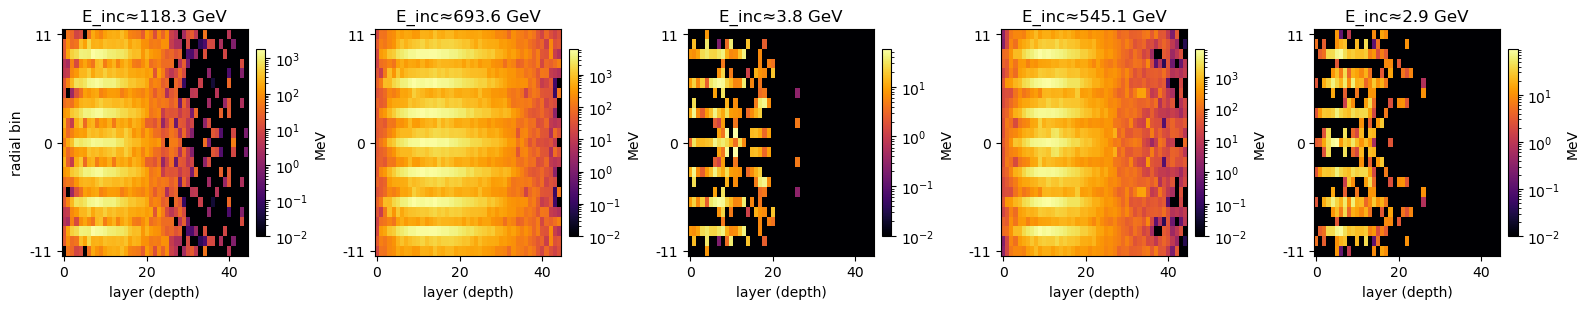

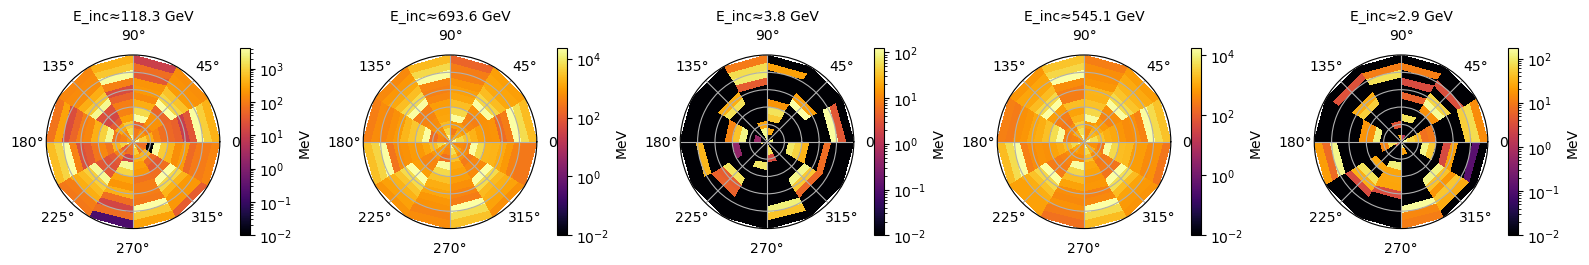

In [60]:
with h5py.File(H5_PATH, "r") as f:
    n_show = 5
    showers = f["showers"][:n_show].reshape(n_show, LAYERS, N_ALPHA, N_R)
    energies_mev = f["incident_energies"][:n_show, 0]

plot_longitudinal(showers, energies_mev, n_show=n_show)
plot_transverse(showers, energies_mev, n_show=n_show)

Data Preprocession

In [33]:
class CaloChallengeDataset(Dataset):

    def __init__(self, h5_path):
        self.h5_path = h5_path

        with h5py.File(h5_path, "r") as f:
            self.energies = f["incident_energies"][:].astype(np.float32)
            self.showers = f["showers"][:].astype(np.float32)

    def __len__(self):
        return len(self.showers)

    def __getitem__(self, idx):

        # Dataset 2 geometry
        shower = self.showers[idx].reshape(45, 16, 9)

        # Same preprocessing as train_upscale.py
        shower = np.log1p(shower)

        # Pad r dimension: 9 -> 10
        shower = np.pad(
            shower,
            ((0, 0), (0, 0), (0, 1)),
            mode="constant"
        )

        # Continuous energy conditioning
        e_inc = self.energies[idx, 0]
        e_cond = np.log10(e_inc)

        shower = torch.tensor(shower, dtype=torch.float32)
        e_cond = torch.tensor(e_cond, dtype=torch.float32)

        return shower, e_cond

## Transformer Design

In [20]:
def modulate(x, shift, scale): # Adaptive Layer Normalization modulation
    return x * (1 + scale.unsqueeze(1)) + shift.unsqueeze(1)

In [23]:
#################################################################################
# Timestep Embedding (unchanged)
#################################################################################
class TimestepEmbedder(nn.Module):
    def __init__(self, hidden_size, frequency_embedding_size=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(frequency_embedding_size, hidden_size),
            nn.SiLU(),
            nn.Linear(hidden_size, hidden_size),
        )
        self.frequency_embedding_size = frequency_embedding_size

    @staticmethod
    def timestep_embedding(t, dim, max_period=10000):
        half = dim // 2
        freqs = torch.exp(
            -math.log(max_period) * torch.arange(0, half, dtype=torch.float32) / half
        ).to(device=t.device)
        args = t[:, None].float() * freqs[None]
        embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        if dim % 2:
            embedding = torch.cat([embedding, torch.zeros_like(embedding[:, :1])], dim=-1)
        return embedding

    def forward(self, t):
        t_freq = self.timestep_embedding(t, self.frequency_embedding_size)
        return self.mlp(t_freq)

In [24]:
#################################################################################
# Energy Conditioning (continuous, log10(E))
#################################################################################
class EnergyEmbedder(nn.Module):
    def __init__(self, hidden_size, frequency_embedding_size=256):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(frequency_embedding_size, hidden_size),
            nn.SiLU(),
            nn.Linear(hidden_size, hidden_size),
        )
        self.frequency_embedding_size = frequency_embedding_size

    @staticmethod
    def sinusoidal_embedding(e, dim, max_period=10000):
        half = dim // 2
        freqs = torch.exp(
            -math.log(max_period) * torch.arange(0, half, dtype=torch.float32) / half
        ).to(device=e.device)
        args = e[:, None].float() * freqs[None]
        emb = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
        if dim % 2:
            emb = torch.cat([emb, torch.zeros_like(emb[:, :1])], dim=-1)
        return emb

    def forward(self, e_cond):
        e_freq = self.sinusoidal_embedding(e_cond, self.frequency_embedding_size)
        return self.mlp(e_freq)

In [25]:
#################################################################################
# Config Conditioning (NEW) — tells the model which geometry (ds2 vs ds3)
#################################################################################
class ConfigEmbedder(nn.Module):
    def __init__(self, hidden_size, num_configs):
        super().__init__()
        self.embed = nn.Embedding(num_configs, hidden_size)

    def forward(self, config_idx):
        # config_idx: LongTensor (B,) of config indices
        return self.embed(config_idx)

In [26]:
#################################################################################
# DiT Block
#################################################################################
class DiTBlock(nn.Module):
    def __init__(self, hidden_size, num_heads, mlp_ratio=4.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(hidden_size, elementwise_affine=False, eps=1e-6)
        self.attn = Attention(hidden_size, num_heads=num_heads, qkv_bias=True)
        self.norm2 = nn.LayerNorm(hidden_size, elementwise_affine=False, eps=1e-6)

        mlp_hidden_dim = int(hidden_size * mlp_ratio)
        approx_gelu = lambda: nn.GELU(approximate="tanh")
        self.mlp = Mlp(in_features=hidden_size, hidden_features=mlp_hidden_dim,
                        act_layer=approx_gelu, drop=0)

        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(hidden_size, 6 * hidden_size)
        )

    def forward(self, x, c):
        shift_msa, scale_msa, gate_msa, \
        shift_mlp, scale_mlp, gate_mlp = \
            self.adaLN_modulation(c).chunk(6, dim=1)

        mod_tokens = modulate(self.norm1(x), shift_msa, scale_msa)

        B, N, C = mod_tokens.shape
        qkv = self.attn.qkv(mod_tokens)
        qkv = qkv.reshape(B, N, 3, self.attn.num_heads, C // self.attn.num_heads)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = (q @ k.transpose(-2, -1)) * self.attn.scale
        attn = attn.softmax(dim=-1)

        attn_out = (attn @ v)
        attn_out = attn_out.transpose(1, 2).reshape(B, N, C)
        attn_out = self.attn.proj(attn_out)

        x = x + gate_msa.unsqueeze(1) * attn_out
        x = x + gate_mlp.unsqueeze(1) * self.mlp(modulate(self.norm2(x), shift_mlp, scale_mlp))
        return x


In [27]:
#################################################################################
# Final Layer 
#################################################################################
class FinalLayer(nn.Module):
    def __init__(self, hidden_size, patch_size, out_channels):
        super().__init__()
        self.norm_final = nn.LayerNorm(hidden_size, elementwise_affine=False, eps=1e-6)
        self.linear = nn.Linear(hidden_size, patch_size * patch_size * out_channels)
        self.adaLN_modulation = nn.Sequential(
            nn.SiLU(),
            nn.Linear(hidden_size, 2 * hidden_size)
        )

    def forward(self, x, c):
        shift, scale = self.adaLN_modulation(c).chunk(2, dim=1)
        x = modulate(self.norm_final(x), shift, scale)
        x = self.linear(x)
        return x

In [28]:
#################################################################################
# DiT Model — multi-config version
#################################################################################

# geometry per config, already padded to be patch_size(=2)-divisible
CALO_CONFIGS = {
    "dataset2": dict(input_size=(16, 10), n_r_real=9),   # radial padded 9->10
}

class DiT(nn.Module):
    def __init__(
        self,
        configs=CALO_CONFIGS,
        patch_size=2,
        in_channels=45,          # same for both configs: 45 calo layers as channels
        hidden_size=384,
        depth=12,
        num_heads=6,
        mlp_ratio=4.0,
        learn_sigma=True,
    ):
        super().__init__()

        self.configs = configs
        self.config_names = list(configs.keys())
        self.config_to_idx = {name: i for i, name in enumerate(self.config_names)}

        self.learn_sigma = learn_sigma
        self.in_channels = in_channels
        self.out_channels = in_channels * 2 if learn_sigma else in_channels
        self.patch_size = patch_size
        self.hidden_size = hidden_size

        # SHARED patch embedding conv (plain Conv2d instead of timm's PatchEmbed,
        # so it isn't locked to one fixed img_size - same weights work for any
        # (H, W) as long as in_channels/patch_size match, which they do here)
        self.patch_conv = nn.Conv2d(
            in_channels, hidden_size,
            kernel_size=patch_size, stride=patch_size, bias=True
        )

        self.t_embedder = TimestepEmbedder(hidden_size)
        self.cond_embedder = EnergyEmbedder(hidden_size)
        self.config_embedder = ConfigEmbedder(hidden_size, num_configs=len(configs))

        # per-config positional embeddings + grid sizes (registered as buffers,
        # not learnable - same as the original DiT's fixed sincos embedding)
        self.grid_sizes = {}
        for name, cfg in configs.items():
            H, W = cfg["input_size"]
            h_p, w_p = H // patch_size, W // patch_size
            self.grid_sizes[name] = (h_p, w_p)

            pe = get_2d_sincos_pos_embed(hidden_size, (h_p, w_p))
            self.register_buffer(
                f"pos_embed_{name}",
                torch.from_numpy(pe).float().unsqueeze(0)
            )

        self.blocks = nn.ModuleList([
            DiTBlock(hidden_size, num_heads, mlp_ratio=mlp_ratio)
            for _ in range(depth)
        ])

        self.final_layer = FinalLayer(hidden_size, patch_size, self.out_channels)

        self.initialize_weights()

    def initialize_weights(self):
        def _basic_init(module):
            if isinstance(module, nn.Linear):
                torch.nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
        self.apply(_basic_init)

        w = self.patch_conv.weight.data
        nn.init.xavier_uniform_(w.view([w.shape[0], -1]))
        nn.init.constant_(self.patch_conv.bias, 0)

        nn.init.normal_(self.t_embedder.mlp[0].weight, std=0.02)
        nn.init.normal_(self.t_embedder.mlp[2].weight, std=0.02)
        nn.init.normal_(self.cond_embedder.mlp[0].weight, std=0.02)
        nn.init.normal_(self.cond_embedder.mlp[2].weight, std=0.02)
        nn.init.normal_(self.config_embedder.embed.weight, std=0.02)

        for block in self.blocks:
            nn.init.constant_(block.adaLN_modulation[-1].weight, 0)
            nn.init.constant_(block.adaLN_modulation[-1].bias, 0)

        nn.init.constant_(self.final_layer.adaLN_modulation[-1].weight, 0)
        nn.init.constant_(self.final_layer.adaLN_modulation[-1].bias, 0)
        nn.init.constant_(self.final_layer.linear.weight, 0)
        nn.init.constant_(self.final_layer.linear.bias, 0)

    def unpatchify(self, x, config_name):
        c = self.out_channels
        p = self.patch_size
        h_p, w_p = self.grid_sizes[config_name]

        x = x.reshape(shape=(x.shape[0], h_p, w_p, p, p, c))
        x = torch.einsum('nhwpqc->nchpwq', x)
        imgs = x.reshape(shape=(x.shape[0], c, h_p * p, w_p * p))
        return imgs

    def forward(self, x, t, e_cond, config_name):
        """
        x: (B, 45, H, W) image for the given config_name
        t: (B,) diffusion timesteps
        e_cond: (B,) log10(incident energy)
        config_name: str, one of self.config_names - the WHOLE batch must be
                     the same config (different configs can't share a tensor
                     shape). See train_upscale.py for how to interleave
                     batches across configs during training.
        """
        assert config_name in self.configs, f"unknown config {config_name}"

        pos_embed = getattr(self, f"pos_embed_{config_name}")

        tokens = self.patch_conv(x)                      # (B, hidden, h_p, w_p)
        tokens = tokens.flatten(2).transpose(1, 2)        # (B, N, hidden)
        tokens = tokens + pos_embed

        t_emb = self.t_embedder(t)
        e_emb = self.cond_embedder(e_cond)

        config_idx = torch.full(
            (x.shape[0],), self.config_to_idx[config_name],
            dtype=torch.long, device=x.device
        )
        cfg_emb = self.config_embedder(config_idx)

        c = t_emb + e_emb + cfg_emb

        for block in self.blocks:
            tokens = block(tokens, c)

        tokens = self.final_layer(tokens, c)
        x_out = self.unpatchify(tokens, config_name)
        return x_out

In [29]:
#################################################################################
# Positional Embeddings (rectangular, angular axis circular)
#################################################################################

def get_2d_sincos_pos_embed(embed_dim, grid_size):
    grid_h, grid_w = grid_size
    emb_h = get_1d_sincos_pos_embed_circular(embed_dim // 2, grid_h)
    emb_w = get_1d_sincos_pos_embed_linear(embed_dim // 2, grid_w)

    emb_h_grid = np.repeat(emb_h[:, None, :], grid_w, axis=1)
    emb_w_grid = np.repeat(emb_w[None, :, :], grid_h, axis=0)

    emb = np.concatenate([emb_h_grid, emb_w_grid], axis=-1)
    return emb.reshape(grid_h * grid_w, embed_dim)


def get_1d_sincos_pos_embed_circular(embed_dim, n_positions):
    k = np.arange(1, embed_dim // 2 + 1, dtype=np.float64)
    pos = np.arange(n_positions, dtype=np.float64)
    angle = 2 * np.pi * np.outer(pos, k) / n_positions
    emb_sin = np.sin(angle)
    emb_cos = np.cos(angle)
    emb = np.concatenate([emb_sin, emb_cos], axis=1)
    if emb.shape[1] < embed_dim:
        emb = np.concatenate([emb, np.zeros((n_positions, embed_dim - emb.shape[1]))], axis=1)
    return emb


def get_1d_sincos_pos_embed_linear(embed_dim, n_positions):
    omega = np.arange(embed_dim // 2, dtype=np.float64)
    omega /= embed_dim / 2.
    omega = 1. / 10000 ** omega
    pos = np.arange(n_positions, dtype=np.float64)
    out = np.einsum('m,d->md', pos, omega)
    emb_sin = np.sin(out)
    emb_cos = np.cos(out)
    emb = np.concatenate([emb_sin, emb_cos], axis=1)
    return emb


## Model Training

In [30]:
# Reproducibility
seed = 1234567890
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [57]:
# Paths / settings
SAVE_DIR = "./checkpoints/"
os.makedirs(SAVE_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 2
LR = 1e-4
NUM_WORKERS = 1

In [39]:
dataset = CaloChallengeDataset(H5_PATH)

print("Number of samples:", len(dataset))

x, energy = dataset[0]

print("Shower shape:", x.shape)
print("Conditioning energy:", energy.item())

Number of samples: 10000
Shower shape: torch.Size([45, 16, 10])
Conditioning energy: 5.073093414306641


In [40]:
loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    drop_last=True
)

x_batch, e_batch = next(iter(loader))
print("Batch image shape:", x_batch.shape)
print("Batch energy shape:", e_batch.shape)

Batch image shape: torch.Size([32, 45, 16, 10])
Batch energy shape: torch.Size([32])


In [45]:
NUM_WORKERS = 0
loader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    drop_last=True
)

x_batch, e_batch = next(iter(loader))

print("Batch shower shape:", x_batch.shape)
print("Batch energy shape:", e_batch.shape)

Batch shower shape: torch.Size([32, 45, 16, 10])
Batch energy shape: torch.Size([32])


In [50]:
model = DiT(configs=CALO_CONFIGS).to(device)

ema = deepcopy(model).to(device)

diffusion = create_diffusion(timestep_respacing="")

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=0
)

print("Model and diffusion are ready.")

Model and diffusion are ready.


In [51]:
@torch.no_grad()
def update_ema(ema_model, model, decay=0.9999):

    ema_params = dict(ema_model.named_parameters())
    model_params = dict(model.named_parameters())

    for name, param in model_params.items():
        ema_params[name].mul_(decay).add_(
            param.data,
            alpha=1 - decay
        )

In [58]:
model.train()
for epoch in range(EPOCHS):
    t0 = time.time()
    running_loss = 0.0
    for step, (x, e_cond) in enumerate(loader):
        x = x.to(device)
        e_cond = e_cond.to(device)

        t = torch.randint(0, diffusion.num_timesteps, (x.shape[0],), device=device)

        model_kwargs = {"e_cond": e_cond, "config_name": "dataset2"}

        loss_dict = diffusion.training_losses(model, x, t, model_kwargs)
        loss = loss_dict["loss"].mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        update_ema(ema, model)
        running_loss += loss.item()

    avg_loss = running_loss / len(loader)
    dt = time.time() - t0
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Loss: {avg_loss:.6f} | Time: {dt:.2f} sec")

    # Save checkpoint
    os.makedirs(SAVE_DIR, exist_ok=True)
    CKPT_PATH = os.path.join(SAVE_DIR, "latest.pt")
    checkpoint = {
        "model": model.state_dict(),
        "ema": ema.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch": epoch + 1
    }
    torch.save(checkpoint, CKPT_PATH)
    print(f"Saved: {CKPT_PATH}")

Epoch [1/2] | Loss: 0.176674 | Time: 167.98 sec
Saved: ./checkpoints/latest.pt
Epoch [2/2] | Loss: 0.177029 | Time: 187.70 sec
Saved: ./checkpoints/latest.pt


## Sampling the results

In [63]:
CONFIG_NAME = "dataset2"          
CKPT_PATH = os.path.join(SAVE_DIR, "latest.pt")  
USE_EMA = True

VOXEL_THRESHOLD_MEV = 0.015       
N_R_REAL = CALO_CONFIGS[CONFIG_NAME]["n_r_real"]  

In [64]:
def load_model(checkpoint_path, device, use_ema=True):
    model = DiT(configs=CALO_CONFIGS).to(device)
    ckpt = torch.load(checkpoint_path, map_location=device)
    state_dict = ckpt["ema"] if use_ema else ckpt["model"]
    model.load_state_dict(state_dict)
    model.eval()
    print(f"Loaded {'EMA' if use_ema else 'raw'} weights from {checkpoint_path} "
          f"(epoch {ckpt.get('epoch', '?')})")
    return model

sampling_model = load_model(CKPT_PATH, device, use_ema=USE_EMA)

Loaded EMA weights from ./checkpoints/latest.pt (epoch 2)


In [65]:
@torch.no_grad()
def sample_showers(model, config_name, energies_mev, device, apply_threshold=True):
    N = len(energies_mev)
    e_cond = torch.tensor([math.log10(e) for e in energies_mev], dtype=torch.float32).to(device)

    sample_diffusion = create_diffusion(timestep_respacing="ddim100")

    cfg = CALO_CONFIGS[config_name]
    shape = (N, 45, *cfg["input_size"])
    noise = torch.randn(*shape, device=device)

    model_kwargs = dict(e_cond=e_cond, config_name=config_name)

    samples = sample_diffusion.ddim_sample_loop(
        model, shape, noise=noise, clip_denoised=False,
        model_kwargs=model_kwargs, progress=True, device=device,
    )
    samples = samples.cpu().numpy()

    samples = np.clip(samples, -20, 20)     # keep expm1 finite for undertrained checkpoints
    samples = np.expm1(samples)             # invert log1p compression
    samples = np.clip(samples, 0, None)     # clip tiny negative diffusion noise

    if apply_threshold:
        samples[samples < VOXEL_THRESHOLD_MEV] = 0.0

    samples = samples[:, :, :, :cfg["n_r_real"]]   # strip radial padding
    return samples   # (N, 45, H, n_r_real) in MeV

In [66]:
energies_gev = [1, 10, 100, 500, 1000]
energies_mev = [e * 1000.0 for e in energies_gev]

generated = sample_showers(sampling_model, CONFIG_NAME, energies_mev, device, apply_threshold=True)

print("Generated shape:", generated.shape)
for i, e in enumerate(energies_mev):
    print(f"  sample {i}: E_inc={e:.0f} MeV | E_dep={generated[i].sum():.0f} MeV | "
          f"nonzero voxels={np.count_nonzero(generated[i])}")

  0%|          | 0/100 [00:00<?, ?it/s]

Generated shape: (5, 45, 16, 9)
  sample 0: E_inc=1000 MeV | E_dep=1420365135872 MeV | nonzero voxels=3265
  sample 1: E_inc=10000 MeV | E_dep=1408069664768 MeV | nonzero voxels=3271
  sample 2: E_inc=100000 MeV | E_dep=1425479958528 MeV | nonzero voxels=3292
  sample 3: E_inc=500000 MeV | E_dep=1396858945536 MeV | nonzero voxels=3223
  sample 4: E_inc=1000000 MeV | E_dep=1405340221440 MeV | nonzero voxels=3233


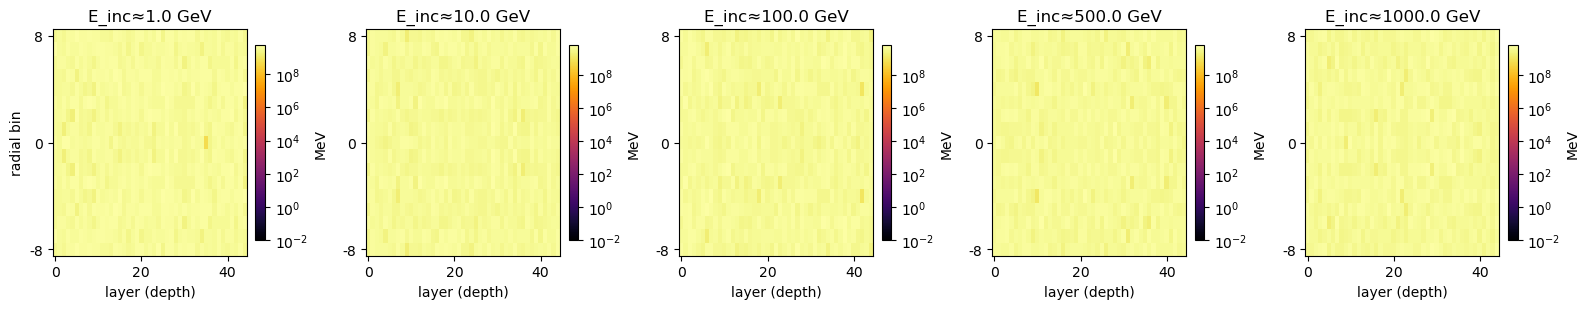

In [67]:
def _mirror_radial(img_r_first):
    return np.concatenate([img_r_first[:0:-1], img_r_first], axis=0)

def plot_longitudinal(showers, energies_mev, n_show=5):
    n_show = min(n_show, len(showers))
    fig, axes = plt.subplots(1, n_show, figsize=(3.2 * n_show, 3.2), squeeze=False)
    for i in range(n_show):
        img = np.nan_to_num(showers[i].sum(axis=1), nan=0.0, posinf=0.0, neginf=0.0)
        n_r = img.shape[1]
        img_mirrored = _mirror_radial(img.T)
        vmax = img_mirrored.max() if img_mirrored.max() > 1e-2 else 1e-1

        ax = axes[0][i]
        im = ax.imshow(img_mirrored + 1e-3, norm=LogNorm(vmin=1e-2, vmax=vmax),
                        aspect="auto", origin="lower", cmap="inferno")
        ax.set_title(f"E_inc≈{energies_mev[i]/1000:.1f} GeV")
        ax.set_xlabel("layer (depth)")
        if i == 0:
            ax.set_ylabel("radial bin")
        ax.set_yticks([0, n_r - 1, 2 * n_r - 2])
        ax.set_yticklabels([f"-{n_r-1}", "0", f"{n_r-1}"])
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="MeV")
    plt.tight_layout()
    plt.show()

plot_longitudinal(generated, energies_mev)

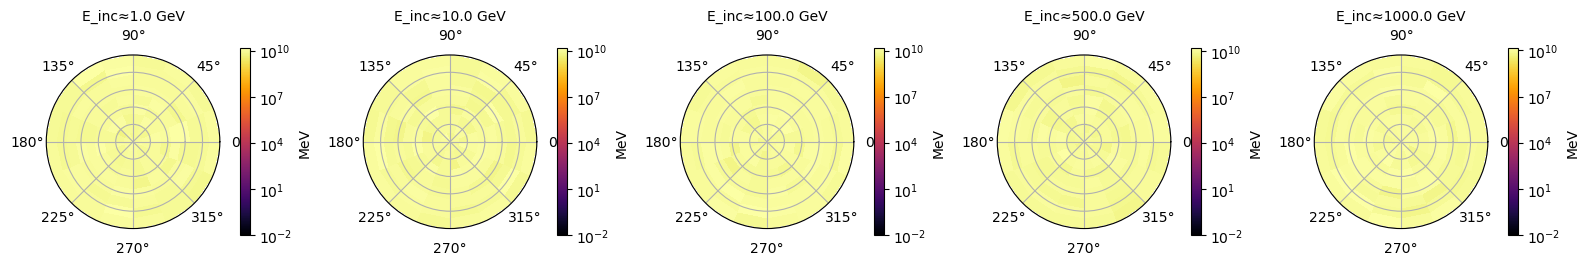

In [68]:
def plot_transverse(showers, energies_mev, n_show=5):
    n_show = min(n_show, len(showers))
    n_alpha, n_r = showers.shape[2], showers.shape[3]
    theta_edges = np.linspace(0, 2 * np.pi, n_alpha + 1)
    r_edges = np.linspace(0, 1, n_r + 1)
    Theta, R = np.meshgrid(theta_edges, r_edges)

    fig, axes = plt.subplots(1, n_show, figsize=(3.2 * n_show, 3.2),
                              subplot_kw={"projection": "polar"}, squeeze=False)
    for i in range(n_show):
        vals = np.nan_to_num(showers[i].sum(axis=0).T, nan=0.0, posinf=0.0, neginf=0.0)
        vmax = vals.max() if vals.max() > 1e-2 else 1e-1
        ax = axes[0][i]
        mesh = ax.pcolormesh(Theta, R, vals + 1e-3, norm=LogNorm(vmin=1e-2, vmax=vmax),
                              cmap="inferno", shading="auto")
        ax.set_title(f"E_inc≈{energies_mev[i]/1000:.1f} GeV", fontsize=10)
        ax.set_yticklabels([])
        plt.colorbar(mesh, ax=ax, fraction=0.046, pad=0.1, label="MeV")
    plt.tight_layout()
    plt.show()

plot_transverse(generated, energies_mev)

In [73]:
CONFIG_NAME = "dataset2"
REAL_H5_PATH = H5_PATH          # your real ground-truth file
NUM_EVAL_SAMPLES = 50          # keep modest for a notebook - full eval can be slow
GEN_BATCH_SIZE = 64

VOXEL_THRESHOLD_MEV = {"dataset2": 0.01515, "dataset3": 0.01515}
LOG1P_CLIP_MAX = {"dataset2": 9.62, "dataset3": 9.26}
LOG1P_CLIP_MIN = -20.0

In [74]:
def _make_clamp_fn(clip_min, clip_max):
    def denoised_fn(x0_pred):
        return torch.clamp(x0_pred, clip_min, clip_max)
    return denoised_fn

@torch.no_grad()
def generate_batched(model, config_name, energies_mev, device, gen_batch_size=64,
                      timestep_respacing="ddim500", apply_threshold=True):
    cfg = CALO_CONFIGS[config_name]
    n_r_real = cfg["n_r_real"]
    gen_diffusion = create_diffusion(timestep_respacing=timestep_respacing)
    clamp_fn = _make_clamp_fn(LOG1P_CLIP_MIN, LOG1P_CLIP_MAX[config_name])

    all_samples = []
    N = len(energies_mev)
    for start in range(0, N, gen_batch_size):
        chunk = energies_mev[start:start + gen_batch_size]
        e_cond = torch.tensor([math.log10(e) for e in chunk], dtype=torch.float32).to(device)
        shape = (len(chunk), 45, *cfg["input_size"])
        noise = torch.randn(*shape, device=device)
        model_kwargs = dict(e_cond=e_cond, config_name=config_name)

        samples = gen_diffusion.ddim_sample_loop(
            model, shape, noise=noise, clip_denoised=False, denoised_fn=clamp_fn,
            model_kwargs=model_kwargs, progress=False, device=device,
        )
        samples = samples.cpu().numpy()
        samples = np.clip(samples, LOG1P_CLIP_MIN, LOG1P_CLIP_MAX[config_name])
        samples = np.expm1(samples)
        samples = np.clip(samples, 0, None)
        if apply_threshold:
            samples[samples < VOXEL_THRESHOLD_MEV[config_name]] = 0.0
        samples = samples[:, :, :, :n_r_real]

        all_samples.append(samples)
        print(f"  generated {min(start + gen_batch_size, N)}/{N}")

    return np.concatenate(all_samples, axis=0)

In [75]:
with h5py.File(REAL_H5_PATH, "r") as f:
    real_energies_full = f["incident_energies"][:, 0]
    real_showers_full = f["showers"][:]

geom = GEOMETRY[CONFIG_NAME] if "GEOMETRY" in dir() else (45, *CALO_CONFIGS[CONFIG_NAME]["input_size"])
# fallback geom dict matching the scripts, in case GEOMETRY isn't defined in your notebook yet
GEOMETRY = {"dataset2": (45, 16, 9), "dataset3": (45, 50, 18)}
geom = GEOMETRY[CONFIG_NAME]

N = min(NUM_EVAL_SAMPLES, len(real_energies_full))
idx = np.random.choice(len(real_energies_full), size=N, replace=False)

real_energies_mev = real_energies_full[idx]
real_showers = real_showers_full[idx].reshape(N, *geom)

gen_showers = generate_batched(
    sampling_model, CONFIG_NAME, real_energies_mev.tolist(), device,
    gen_batch_size=GEN_BATCH_SIZE, apply_threshold=True,
)
print("real_showers:", real_showers.shape, "gen_showers:", gen_showers.shape)

  generated 50/50
real_showers: (50, 45, 16, 9) gen_showers: (50, 45, 16, 9)


In [76]:
def compute_total_energy(showers):
    return showers.sum(axis=(1, 2, 3))

def compute_energy_profile_layer(showers):
    return showers.sum(axis=(2, 3)).mean(axis=0)  # (layers,)

real_E_tot = compute_total_energy(real_showers)
gen_E_tot = compute_total_energy(gen_showers)

real_energy_layer = compute_energy_profile_layer(real_showers)
gen_energy_layer = compute_energy_profile_layer(gen_showers)

/var/folders/73/n2lzmpj52ylddyg0khvbr5cw0000gn/T/ipykernel_87100/1293272175.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


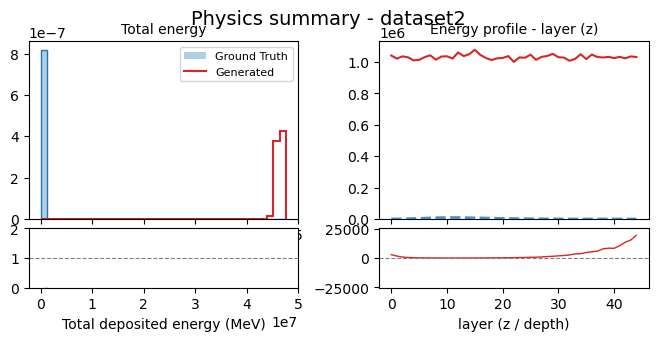

In [77]:
import matplotlib.pyplot as plt

def _draw_hist_panel(ax_main, ax_ratio, real_vals, gen_vals, n_bins=40):
    lo = min(real_vals.min(), gen_vals.min())
    hi = max(real_vals.max(), gen_vals.max())
    bins = np.linspace(lo, hi, n_bins)

    real_counts, edges = np.histogram(real_vals, bins=bins, density=True)
    gen_counts, _ = np.histogram(gen_vals, bins=bins, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])

    ax_main.stairs(real_counts, edges, fill=True, alpha=0.35, color="tab:blue", label="Ground Truth")
    ax_main.stairs(real_counts, edges, fill=False, color="tab:blue", linewidth=1.0)
    ax_main.stairs(gen_counts, edges, fill=False, color="tab:red", linewidth=1.5, label="Generated")

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(real_counts > 0, gen_counts / real_counts, np.nan)
    ax_ratio.step(centers, ratio, where="mid", color="tab:red", linewidth=1.0)
    ax_ratio.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
    ax_ratio.set_ylim(0, 2)
    ax_ratio.set_yticks([0, 1, 2])

def _draw_profile_panel(ax_main, ax_ratio, real_curve, gen_curve):
    x = np.arange(len(real_curve))
    ax_main.plot(x, real_curve, color="tab:blue", linewidth=2.0, linestyle="--", alpha=0.8, label="Ground Truth")
    ax_main.plot(x, gen_curve, color="tab:red", linewidth=1.5, label="Generated")
    ax_main.set_ylim(bottom=0)

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(real_curve > 0, gen_curve / real_curve, np.nan)
    ax_ratio.plot(x, ratio, color="tab:red", linewidth=1.0)
    ax_ratio.axhline(1.0, color="gray", linestyle="--", linewidth=0.8)
    finite_ratio = ratio[np.isfinite(ratio)]
    max_dev = np.max(np.abs(finite_ratio - 1.0)) if len(finite_ratio) else 0.5
    pad = max(max_dev * 1.3, 0.1)
    ax_ratio.set_ylim(1 - pad, 1 + pad)

fig = plt.figure(figsize=(8, 3.2))
gs = fig.add_gridspec(1, 2, wspace=0.3)

# Panel 1: total energy
inner1 = gs[0, 0].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08)
ax1_main = fig.add_subplot(inner1[0])
ax1_ratio = fig.add_subplot(inner1[1], sharex=ax1_main)
_draw_hist_panel(ax1_main, ax1_ratio, real_E_tot, gen_E_tot)
ax1_main.set_title("Total energy", fontsize=10)
ax1_ratio.set_xlabel("Total deposited energy (MeV)")

# Panel 2: energy profile layer (z)
inner2 = gs[0, 1].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08)
ax2_main = fig.add_subplot(inner2[0])
ax2_ratio = fig.add_subplot(inner2[1], sharex=ax2_main)
_draw_profile_panel(ax2_main, ax2_ratio, real_energy_layer, gen_energy_layer)
ax2_main.set_title("Energy profile - layer (z)", fontsize=10)
ax2_ratio.set_xlabel("layer (z / depth)")

ax1_main.legend(fontsize=8)
fig.suptitle(f"Physics summary - {CONFIG_NAME}", fontsize=14)
plt.tight_layout()
plt.show()

## Performance Evaluation

## References

- X.T. Nguyen et al., “Differentiable Surrogate for Detector Simulation and Design with Diffusion Models,” MLST 7, 025061 (2026). arXiv:2601.07859.

- W. Peebles et al., “Scalable Diffusion Models with Transformers,” arXiv:2212.09748 (2022).

- J. Ho et al., “Denoising Diffusion Probabilistic Models,” NeurIPS 33, 6840-6851 (2020). arXiv:2006.11239.

- J. Song et al., “Denoising Diffusion Implicit Models,” ICLR 2021, (2021). arXiv:2010.02502.